In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pydas.simulation_manager import BuildingEnergySimulator, RCBuilding1R1C, SupplyController

parameters_1R1C = {
    "thermal_capacitance": 5.0, # In units of kWh / K.,
    "thermal_conductance": 0.5 # In units of Kw / K. 
}

In [13]:
bes = BuildingEnergySimulator(timestep = 1.0) # Time step is one hour [Units of hour is used by default].
bes.load_outdoor_temperature_data("../data/smhi_gotenburg.csv") # For now, loading a weather file that has at least hourly resolution.
controller = SupplyController(maximum_heating_power = 10.0) # An external "controller" that supplies heating power instantaneously.
rcbuilding = RCBuilding1R1C(parameters = parameters_1R1C) # Represent a 1R1C model of building heat loss as first test.
bes.add_rcbuilding(rcbuilding) # Lets the simulator orchestrator have access to building members and methods.
bes.add_controller(controller) # Lets the simulator orchestrator have access to controller members and methods.

In [14]:
recorded_indoor_temperatures = []
recorded_setpoints = []
number_of_iterations = len(bes.outdoor_temperature_data.index)
print(f"Simulation will contain {number_of_iterations} one-hour timesteps.")

Simulation will contain 3139 one-hour timesteps.


In [15]:
%%time
for it in range(number_of_iterations):
    recorded_setpoints.append(rcbuilding.setpoint_temperature_callback(bes.outdoor_temperature_data["timestamp"].dt.hour[it])) # Get the current setpoint temperature, based on a very simple rule.
    recorded_indoor_temperatures.append(bes.rcbuilding.state["indoor_temperature"]) # Get the corresponding instantaneous indoor temperature.
    bes.step() # Update the simulation one hour forward (one timestep).

CPU times: total: 875 ms
Wall time: 883 ms


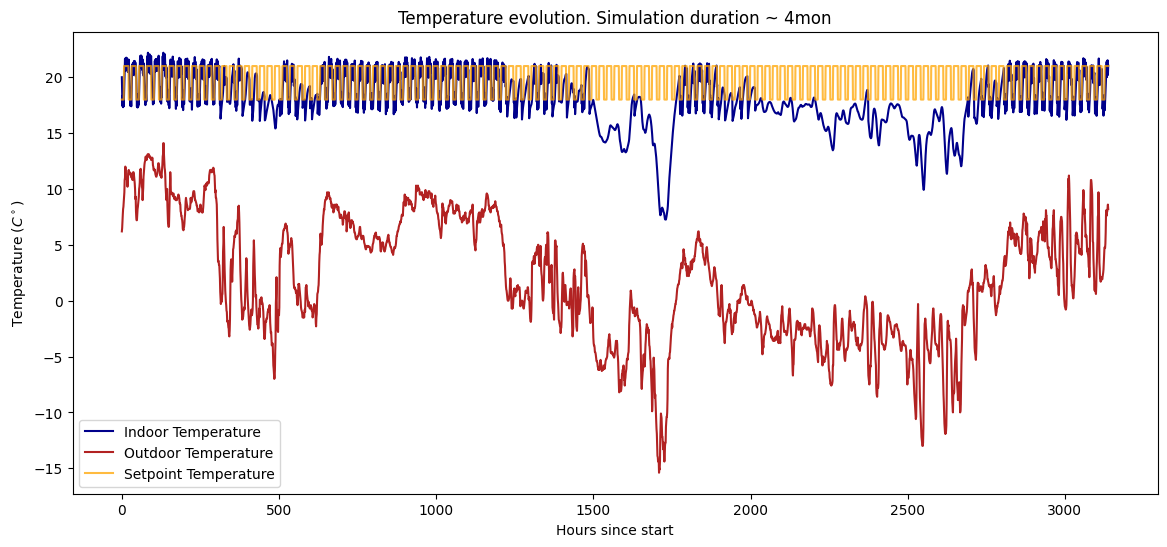

In [33]:
plt.figure(figsize = (14, 6))
plt.plot(recorded_indoor_temperatures, label = "Indoor Temperature", color = "darkblue")
plt.plot(bes.outdoor_temperature_data["Lufttemperatur"], label = "Outdoor Temperature", color = "firebrick")
plt.plot(recorded_setpoints, color = "orange", label = "Setpoint Temperature", alpha = 0.75)
plt.title("Temperature evolution. Simulation duration ~ 4mon")
plt.xlabel("Hours since start")
plt.ylabel("Temperature $(C^\\circ)$")
plt.legend()

#plt.xlim(1000, 1500)